In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from msfm.utils import prior, parameters, files, logger, observation, scales
from msi.utils import preprocessing, plotting

In [3]:
use_flow = True

if use_flow:
    import torch
    from msi.flow_conductor.likelihood_flow import LikelihoodFlow
    from msi.flow_conductor import architecture
else:
    import tensorflow as tf
    from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
    from msi.gaussian_mixture import architecture

# v14

### lensing

In [4]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0}

# file_label = "8mpc"
# # file_label = "12mpc"

# n_steps = 200_000

### clustering

In [5]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# n_steps = 400_000

# file_label = "32mpc"

### combined

In [6]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# # n_steps = 100_000
# n_steps = 400_000

# file_label = "8,32mpc"
# # file_label += "_lmin=113"

In [7]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v14/extended"
# out_dir_base = "/pscratch/sd/a/athomsen/run_files/v14/cls"

# v15

### lensing

In [8]:
with_lensing = True
with_clustering = False
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0}

file_label = "default"

# n_steps = 300_000
n_steps = 100_000

### clustering

In [9]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# n_steps = 400_000

# file_label = "32mpc"

### combined

In [10]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# n_steps = 300_000

# file_label = "default"

In [11]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v15/extended.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v15/extended"
out_dir_base = "/pscratch/sd/a/athomsen/run_files/v15/cls"

# shared

In [12]:
# n_params = len(params)
# apply_log = True
# standardize = False

# out_dir = os.path.join(out_dir_base, "mutual_info")
# if with_lensing and not with_clustering:
#     out_dir = os.path.join(out_dir, "lensing")
# elif with_clustering and not with_lensing:
#     out_dir = os.path.join(out_dir, "clustering")
# elif with_lensing and with_clustering:
#     out_dir = os.path.join(out_dir, "combined")
# out_dir = os.path.join(out_dir, f"standard={standardize},log={apply_log},steps={n_steps}")

# pred_file = os.path.join(out_dir, file_label, "preds.h5")
# print(f"pred_file = {pred_file}")

In [13]:
# pred_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/base_penultimate/preds.h5"
# pred_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/sw_penultimate_100/preds.h5"
# pred_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/sw_penultimate_100_300k/preds.h5"
# pred_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/base_penultimate/preds.h5"
# pred_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/base/preds.h5"
pred_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/sw_analytical/preds.h5"
# pred_file = "/pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/base_300k/preds.h5"

out_dir = os.path.dirname(pred_file)

In [14]:
def try_mock(f, mock):
    try:
        pred = f[f"mocks/pred/{mock}"][:]
        print(f"Read {mock} predictions")
        
        return pred
    except:
        print(f"There is no {mock} mock in the file")
        
with h5py.File(pred_file, "r") as f:
    grid_preds = f["grid/preds/test"][:]
    grid_cosmos = f["grid/cosmos/test"][:]
    fidu_preds = f["fidu/preds"][:]
    
    buzzard_pred = try_mock(f, "Buzzard")
    buzzard_pred_dnf = try_mock(f, "Buzzard_mocked_DNF")
    cardinal_pred = try_mock(f, "Cardinal")
    
    mice_pred = try_mock(f, "MICE")
    euclid_pred = try_mock(f, "Euclid")
    
print(grid_preds.shape)
print(grid_cosmos.shape)

There is no Buzzard mock in the file
There is no Buzzard_mocked_DNF mock in the file
There is no Cardinal mock in the file
There is no MICE mock in the file
There is no Euclid mock in the file
(200000, 6)
(200000, 6)


# normalizing flow $p(x | \theta)$

### initialization

In [15]:
model = LikelihoodFlow(
    params, 
    conf, 
    feature_dim=grid_preds.shape[-1],    
    out_dir=out_dir, 
    label=file_label,
    load_existing=True,
)

26-02-04 05:18:03 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/sw_analytical/default/likelihood_flow 
26-02-04 05:18:03 likelihood_f INF   Using the default context embedding network: 
26-02-04 05:18:03 likelihood_f INF   <class 'enflows.nn.nets.resnet.ResidualNet'> 
26-02-04 05:18:03 likelihood_f INF   Using the default base distribution: 
26-02-04 05:18:03 likelihood_f INF   <class 'enflows.distributions.normal.StandardNormal'> 
26-02-04 05:18:04 likelihood_f INF   Using the default transform: 
26-02-04 05:18:04 likelihood_f INF   <class 'enflows.transforms.base.CompositeTransform'> 
26-02-04 05:18:04 likelihood_f INF   Initialized the normalizing flow 
26-02-04 05:18:04 likelihood_f INF   Running on device cuda with default float torch.float32 
26-02-04 05:18:04 likelihood_f INF   Loaded the model from /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/sw_analytical/default/likelihood_flow/likelihood_flow.pt 


### training

26-02-04 05:18:05 likelihood_f INF   Using a cosine annealing scheduler with lr_min 1e-05 and T_max 100 
100%|████████████████████████████|   | 100/100 [04:27<00:00,  2.67s/it]       lr: 1.00E-05, train: -0.21, vali: -0.06: 
26-02-04 05:22:32 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/sw_analytical/default/likelihood_flow/likelihood_flow.pt 


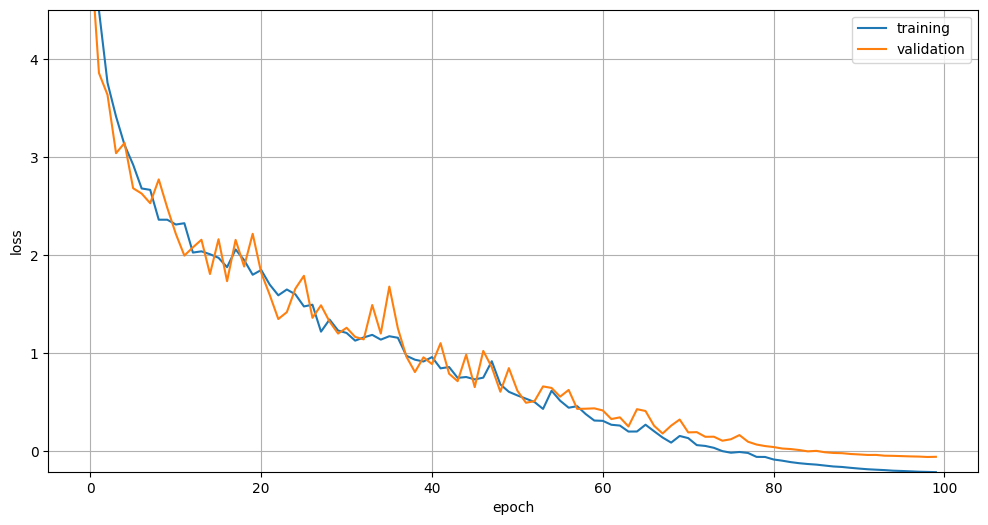

In [16]:
model.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=100,
    batch_size=10_000,
    scheduler_type="cosine",
    save_model=True,
)

# observation

CosmoGrid internal

In [17]:
obs_dict = {}

n_examples = 4
i_examples = 0

for i_grid in range(n_examples):
    i_grid *= 80
    obs_dict[f"grid_{i_grid}"] = {
        "pred": grid_preds[i_grid],
        "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
    }


DES footprint

lensing

# buzzard_pred

In [18]:
# obs_dict = {}

# buzzard_indices = list(range(0, 16))
# buzzard_indices.remove(1)
# with h5py.File(pred_file, "r") as f:
#     buzzard_stack = []
#     for i in buzzard_indices:
#         pred = np.squeeze(f[f"mocks/pred/Buzzard_{i}"])
#         buzzard_stack.append(pred)
#         print(pred)
        
#         # obs_dict[f"Buzzard_{i}"] = {
#         #     "pred": pred,
#         #     "point": buzzard_cosmo,
#         # }

# buzzard_stack = np.stack(buzzard_stack, axis=0)

# obs_dict[f"Buzzard_mean"] = {
#     "pred": np.mean(buzzard_stack, axis=0),
#     "point": buzzard_cosmo,
# }

# obs_dict[f"Buzzard_stack"] = {
#     "pred": np.stack(buzzard_stack, axis=0),
#     "point": buzzard_cosmo,
# }

clustering

In [19]:
# obs_dict = {}

# # bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# bias_dict = {"bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan, "qbg1": np.nan, "qbg2": np.nan, "qbg3": np.nan, "qbg4": np.nan}

# obs_dict["Buzzard"] = {
#     "pred": np.squeeze(buzzard_pred),
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# }

# # obs_dict["Cardinal"] = {
# #     "pred": np.squeeze(cardinal_pred),
# #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, **bias_dict},
# # }

In [20]:
# buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# buzzard_flock_labels = os.listdir(buzzard_flock_dir)
# buzzard_flock_labels = [file[23:-3] for file in buzzard_flock_labels]

# buzzard_flock_preds = []
# with h5py.File(pred_file, "r") as f:
#     for i, buzzard_flock_label in enumerate(buzzard_flock_labels):
#         buzzard = np.squeeze(f[f"mocks/{buzzard_flock_label}"])
#         buzzard_flock_preds.append(buzzard)
        
#         obs_dict[f"Buzzard_{i}"] = {
#             "pred": buzzard,
#             "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
#         }
        
# buzzard_flock_preds = np.stack(buzzard_flock_preds, axis=0)
        
# buzzard_flock_preds = np.stack(buzzard_flock_preds, axis=0)
# obs_dict["Buzzard_flock_stack"] = {
#     "pred": buzzard_flock_preds,
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
# }

# buzzard_flock_mean = np.mean(buzzard_flock_preds, axis=0)
# obs_dict["Buzzard_flock_mean"] = {
#     "pred": buzzard_flock_mean,
#     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
# }

### MCMC and plotting


Starting with mock observation grid_0
26-02-04 05:22:33 likelihood_f INF   Sampling the posterior from a single observation 
26-02-04 05:22:33      mcmc.py INF   Initial values in prior: 46.9% 
26-02-04 05:22:33      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:45<00:00, 21.84it/s]

26-02-04 05:23:19      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:41<00:00, 24.08it/s]

26-02-04 05:24:00      mcmc.py INF   MAP parameters: {'Om': 0.287, 's8': 1.142, 'w0': -0.782, 'Aia': -0.483, 'n_Aia': -2.093, 'bta': 0.386} 
26-02-04 05:24:01      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/sw_analytical/default/likelihood_flow/chain_grid_0.npy 


...

  0%|          | 0/21 [00:00<?, ?it/s]

/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/utils_plots.py:650: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  lis, las = ax[i, j].get_legend_handles_labels()


  0%|          | 0/21 [00:00<?, ?it/s]

/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/utils_plots.py:650: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  lis, las = ax[i, j].get_legend_handles_labels()


26-02-04 05:38:39  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v15/cls/mutual_info/debug/sw_analytical/default/likelihood_flow/contours_grid_240.png 


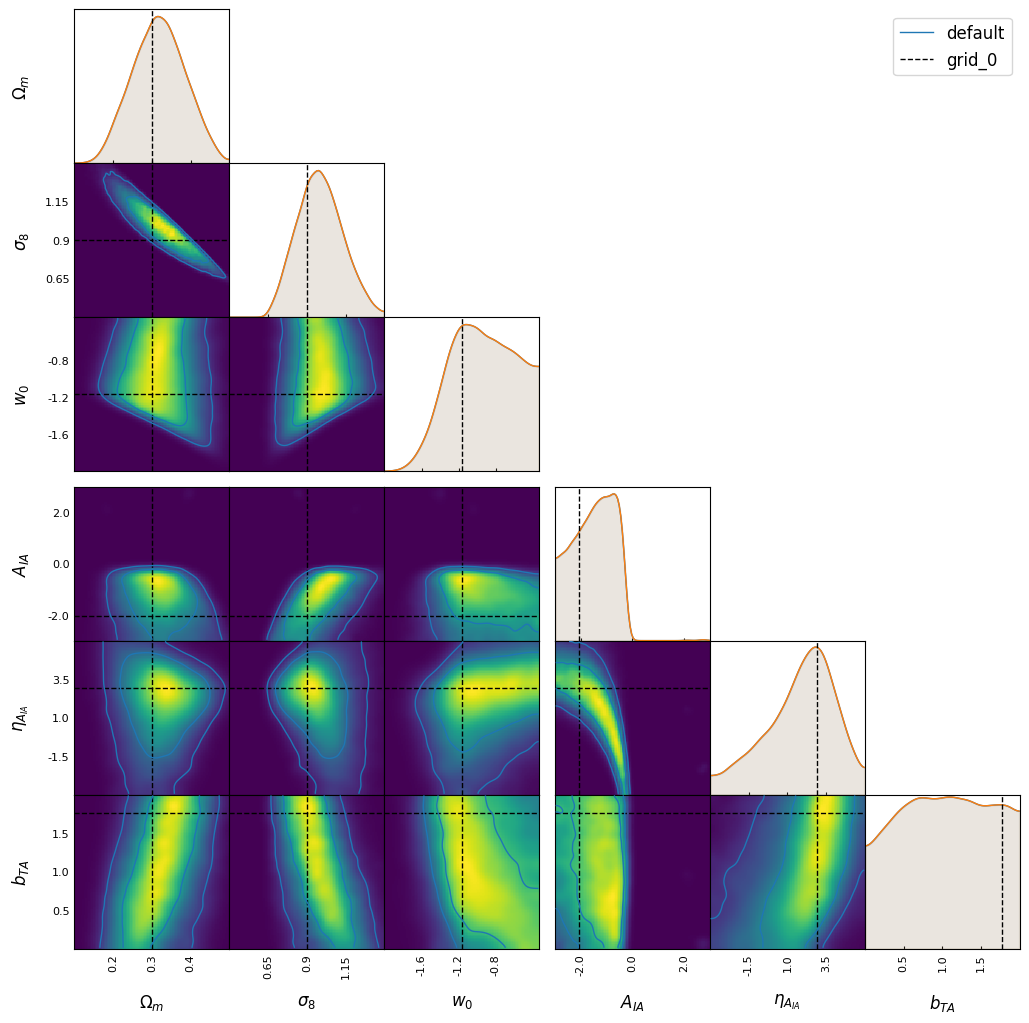

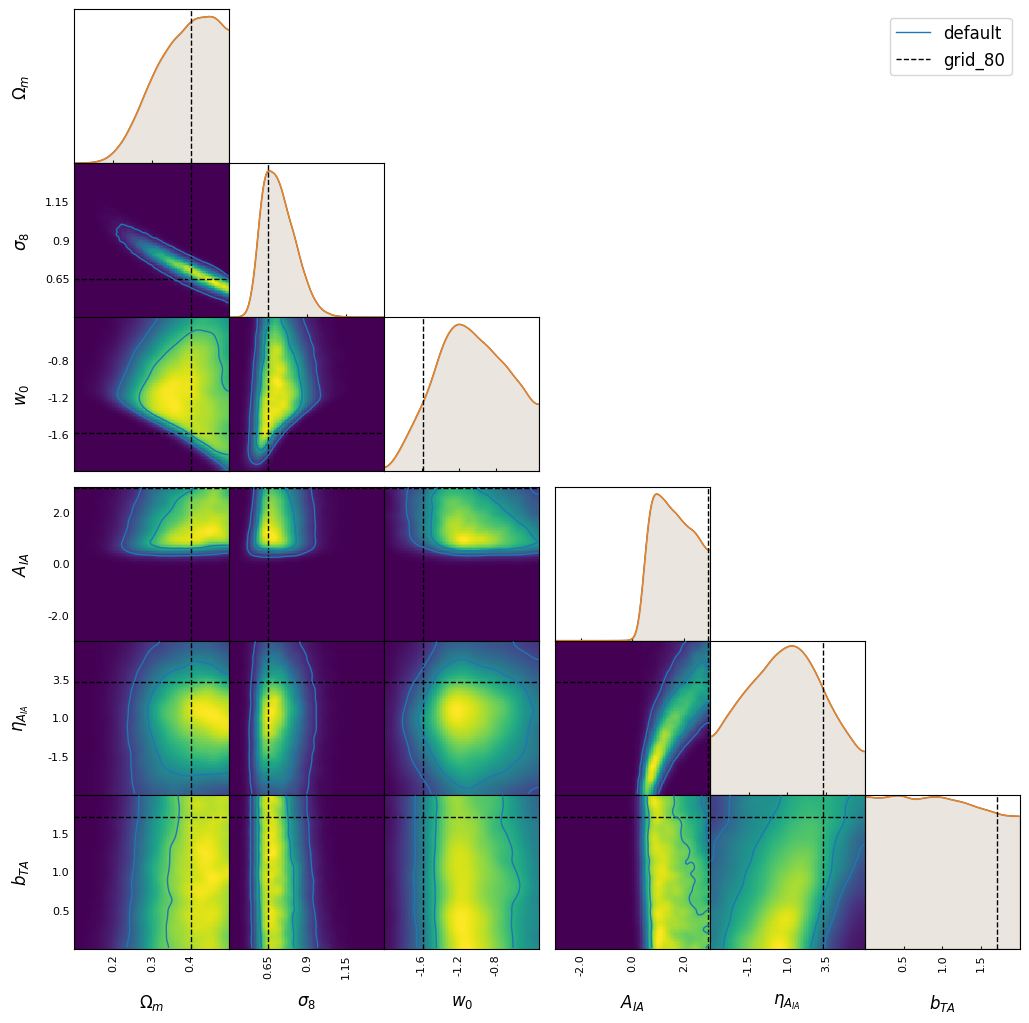

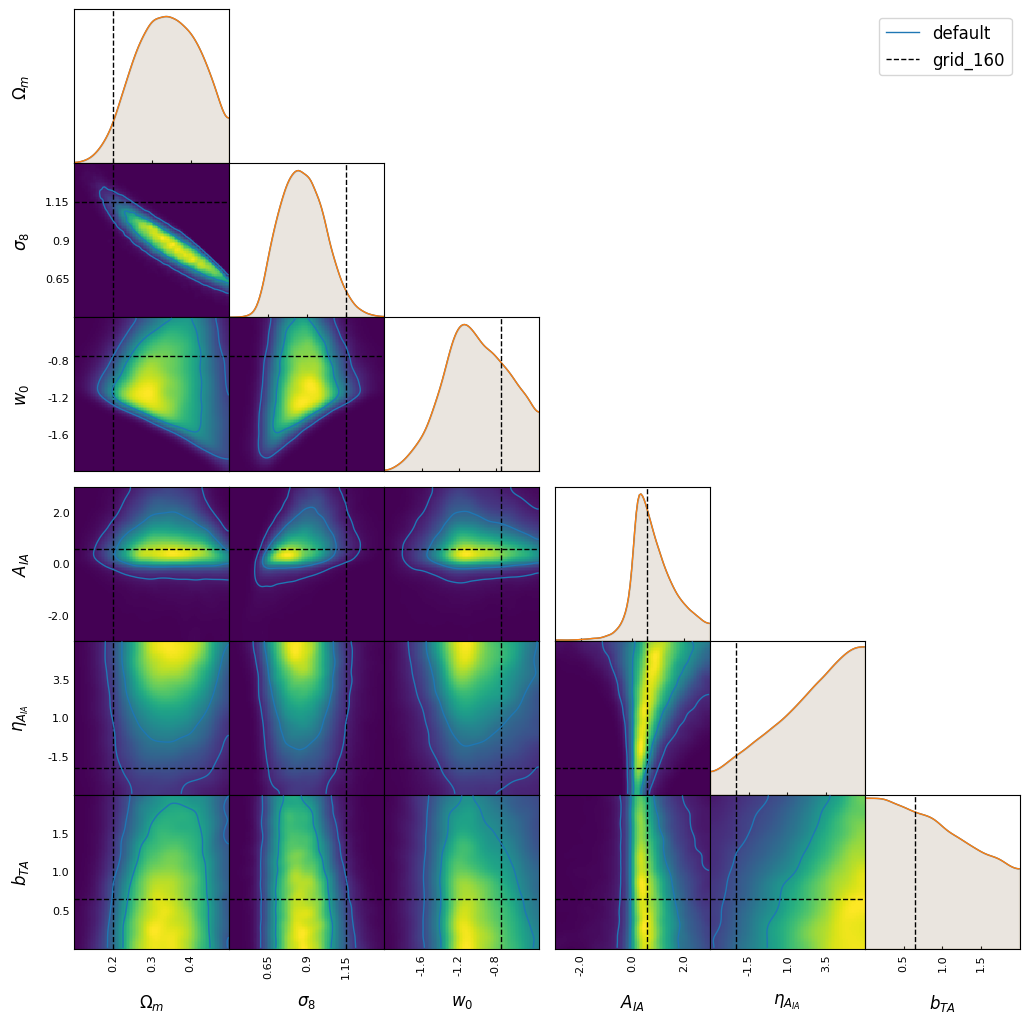

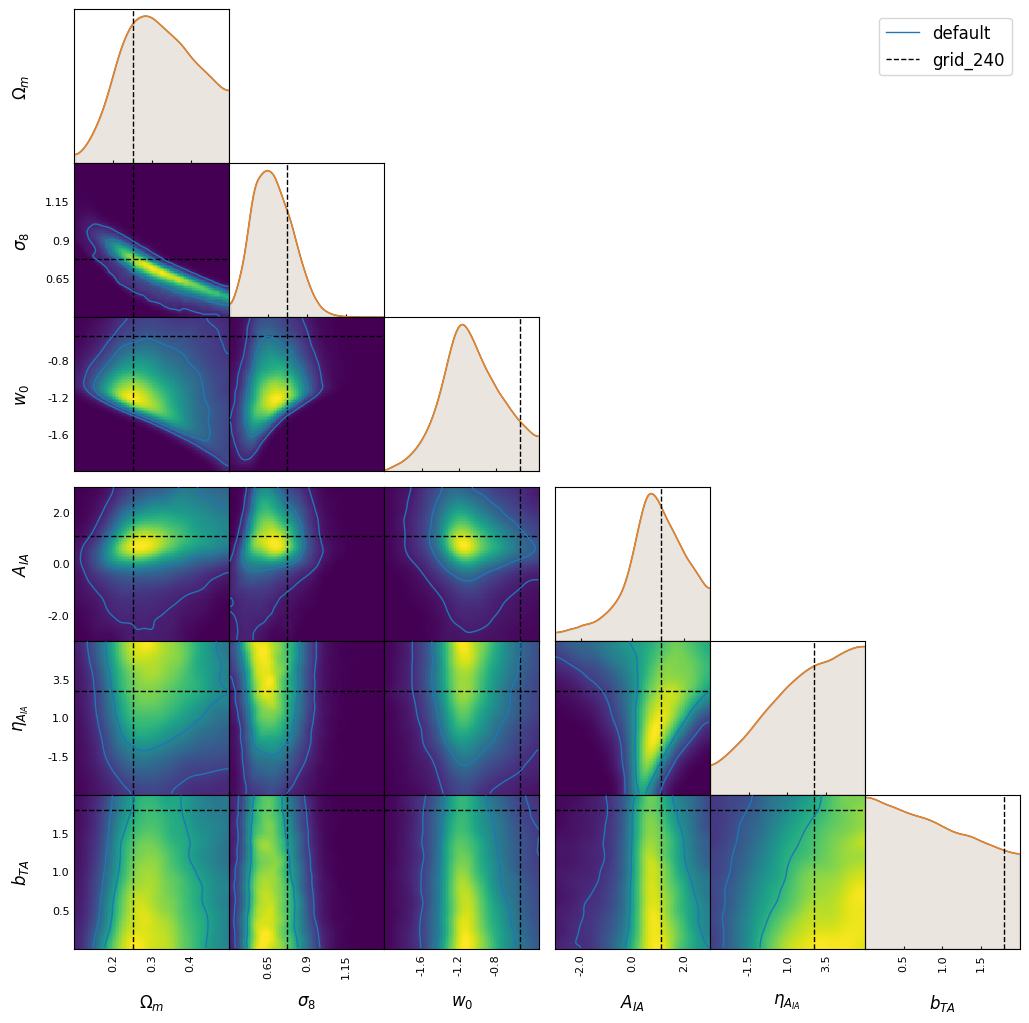

In [21]:
extra_label = ""
# extra_label = "Om=0.3"
# extra_label = f"_n{n_examples}_i{i_examples}_mocks"
# extra_label = f"_gaussian_prior_n{n_examples}_i{i_examples}_mocks"

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    # print(obs_dict[key]["pred"])
    
    posterior_samples = model.sample_posterior(
        obs_dict[key]["pred"],
        label=key+extra_label,
        n_walkers=1024,
        n_burnin_steps=1000,
        n_samples=1024*1000,
    )

    model.plot_contours(
        posterior_samples,
        obs_point=obs_dict[key]["point"],
        obs_label=key,
        label=key+extra_label,
        with_des_chain=False,
        density=True
    )